In [15]:
import pandas as pd

df = pd.read_csv("laptops.csv")
df.head()

,Unnamed: 0,img_link,name,price(in Rs.),processor,ram,os,storage,display(in inch),rating,no_of_ratings,no_of_reviews
0,0,https://rukminim1.flixcart.com/image/312/312/x...,Lenovo Intel Core i5 11th Gen,62990,Intel Core i5 Processor (11th Gen),16 GB DDR4 RAM,Windows 11 Operating System,512 GB SSD,15.6,4.5,14.0,1.0
1,1,https://rukminim1.flixcart.com/image/312/312/x...,Lenovo V15 G2 Core i3 11th Gen,37500,Intel Core i3 Processor (11th Gen),8 GB DDR4 RAM,64 bit Windows 11 Operating System,1 TB HDD|256 GB SSD,15.6,4.4,53.0,3.0
2,2,https://rukminim1.flixcart.com/image/312/312/l...,ASUS TUF Gaming F15 Core i5 10th Gen,49990,Intel Core i5 Processor (10th Gen),8 GB DDR4 RAM,Windows 11 Operating System,512 GB SSD,15.6,4.4,4733.0,463.0
3,3,https://rukminim1.flixcart.com/image/312/312/x...,ASUS VivoBook 15 (2022) Core i3 10th Gen,33990,Intel Core i3 Processor (10th Gen),8 GB DDR4 RAM,64 bit Windows 11 Operating System,512 GB SSD,15.6,4.3,10406.0,1040.0
4,4,https://rukminim1.flixcart.com/image/312/312/x...,Lenovo Athlon Dual Core,18990,AMD Athlon Dual Core Processor,4 GB DDR4 RAM,DOS Operating System,256 GB SSD,14.0,3.8,18.0,3.0


In [2]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        984 non-null    int64  
 1   img_link          984 non-null    object 
 2   name              984 non-null    object 
 3   price(in Rs.)     984 non-null    int64  
 4   processor         984 non-null    object 
 5   ram               984 non-null    object 
 6   os                984 non-null    object 
 7   storage           984 non-null    object 
 8   display(in inch)  984 non-null    float64
 9   rating            688 non-null    float64
 10  no_of_ratings     688 non-null    float64
 11  no_of_reviews     688 non-null    float64
dtypes: float64(4), int64(2), object(6)
memory usage: 92.4+ KB


Unnamed: 0            0
img_link              0
name                  0
price(in Rs.)         0
processor             0
ram                   0
os                    0
storage               0
display(in inch)      0
rating              296
no_of_ratings       296
no_of_reviews       296
dtype: int64

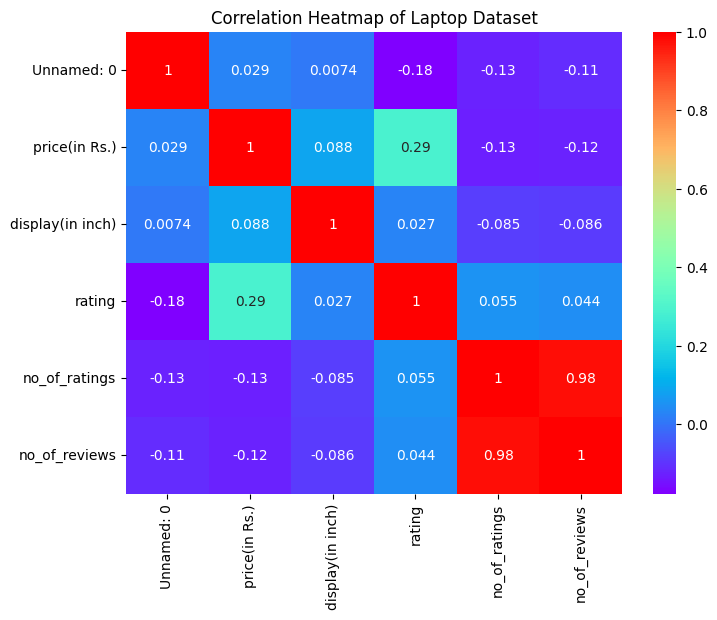

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

num = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(num.corr(), annot=True, cmap='rainbow')
plt.title("Correlation Heatmap of Laptop Dataset")
plt.show()

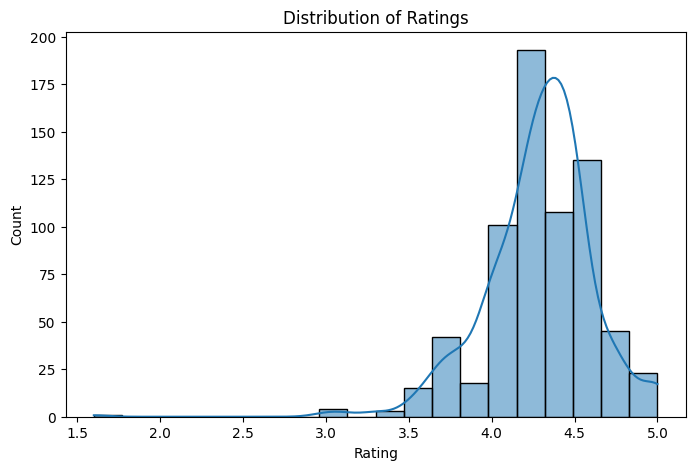

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

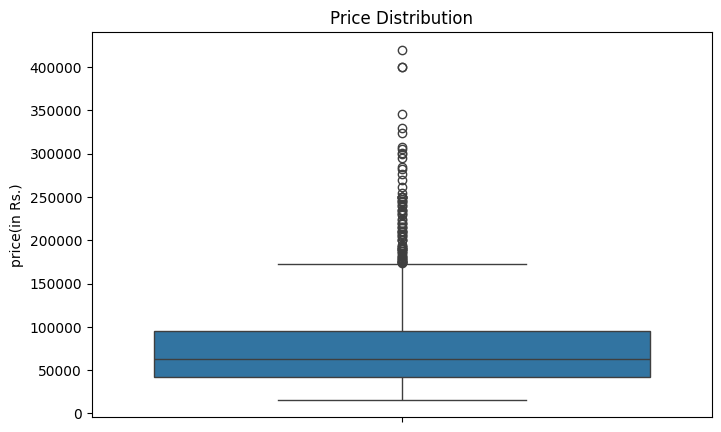

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(y='price(in Rs.)', data=df)

plt.title("Price Distribution")
plt.show()

C:\Users\aldoj\AppData\Local\Temp\ipykernel_23728\1781856786.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


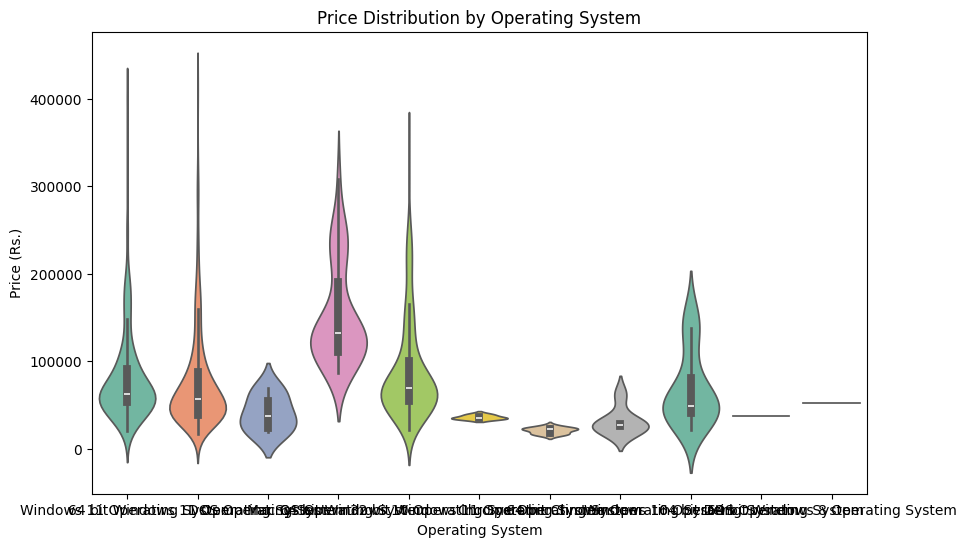

In [6]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='os',
    y='price(in Rs.)',
    data=df,
    palette='Set2'
)

plt.title("Price Distribution by Operating System")
plt.xlabel("Operating System")
plt.ylabel("Price (Rs.)")
plt.show()

C:\Users\aldoj\AppData\Local\Temp\ipykernel_23728\1069580499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='os', data=df, palette='Set2')


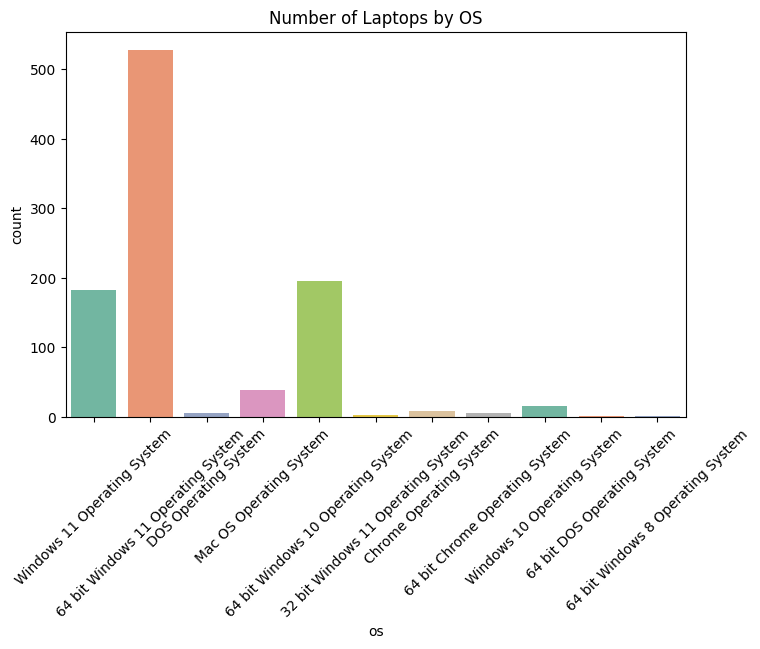

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(x='os', data=df, palette='Set2')

plt.title("Number of Laptops by OS")
plt.xticks(rotation=45)
plt.show()

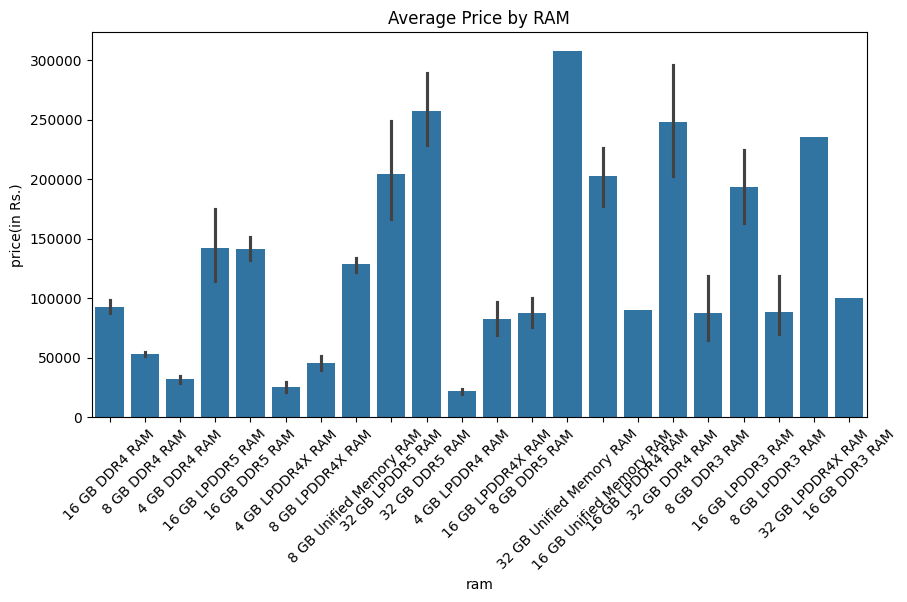

In [8]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='ram',
    y='price(in Rs.)',
    data=df,
    estimator='mean'
)

plt.xticks(rotation=45)
plt.title("Average Price by RAM")
plt.show()

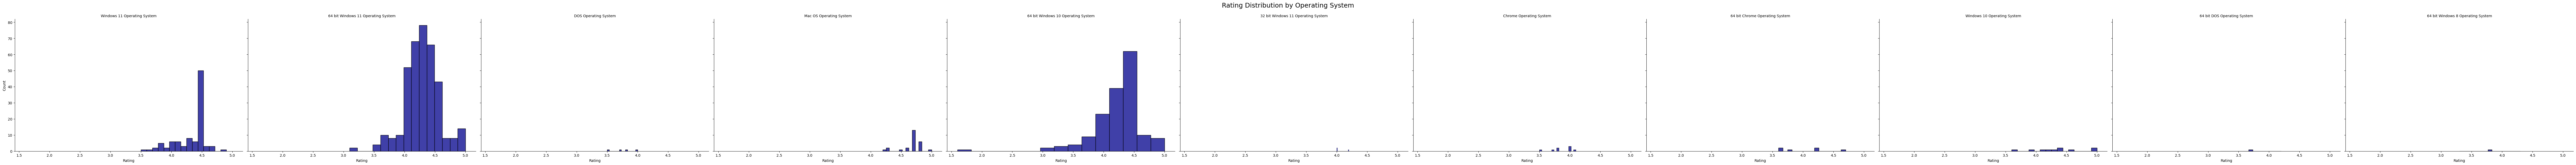

In [9]:
g = sns.FacetGrid(
    df,
    col='os',
    height=6,      # Increase height
    aspect=1.5     # Increase width
)

g.map_dataframe(
    sns.histplot,
    x='rating',
    bins=15,
    color='darkblue'
)

g.set_axis_labels("Rating", "Count")
g.set_titles(col_template="{col_name}")

g.fig.suptitle("Rating Distribution by Operating System", fontsize=18, y=1.05)

plt.show()

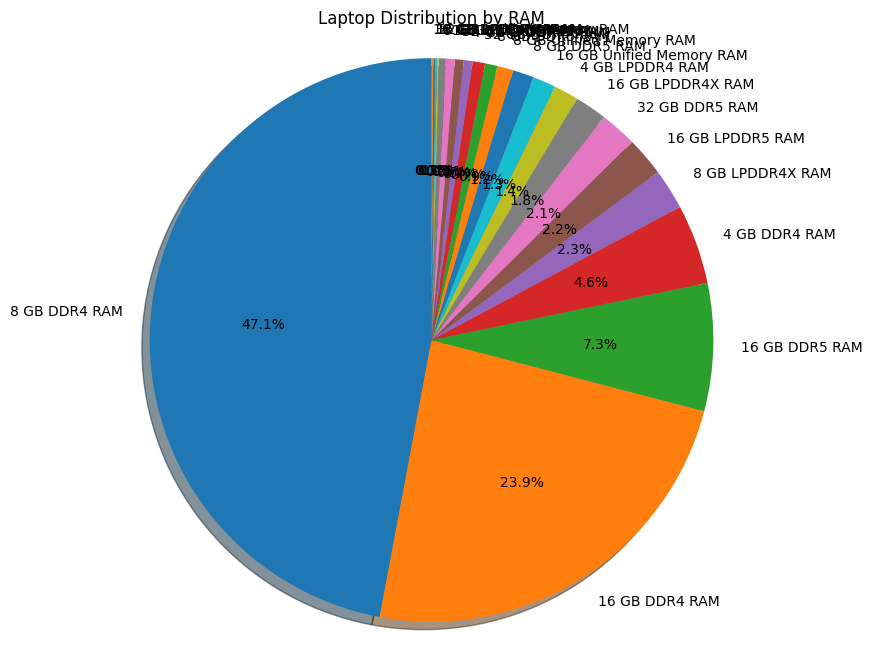

In [10]:

ram_count = df['ram'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    ram_count,
    labels=ram_count.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

plt.title("Laptop Distribution by RAM")

plt.axis('equal')
plt.show()

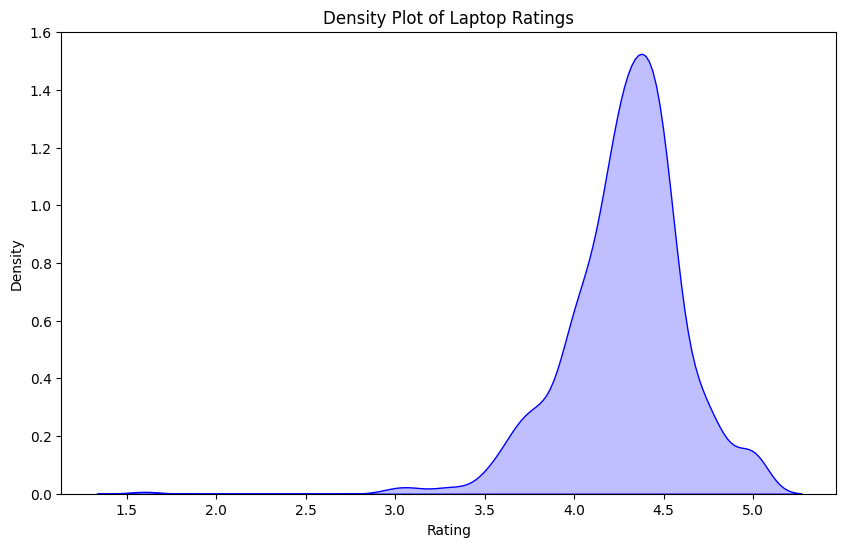

In [11]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='rating',
    fill=True,
    color='blue'
)

plt.title("Density Plot of Laptop Ratings")
plt.xlabel("Rating")
plt.ylabel("Density")

plt.show()

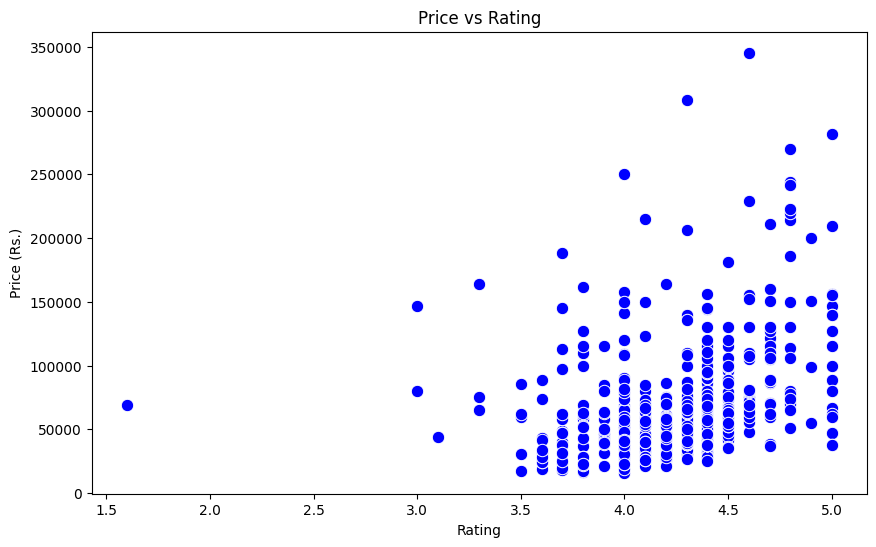

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='rating',
    y='price(in Rs.)',
    color='blue',
    s=80
)

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (Rs.)")

plt.show()

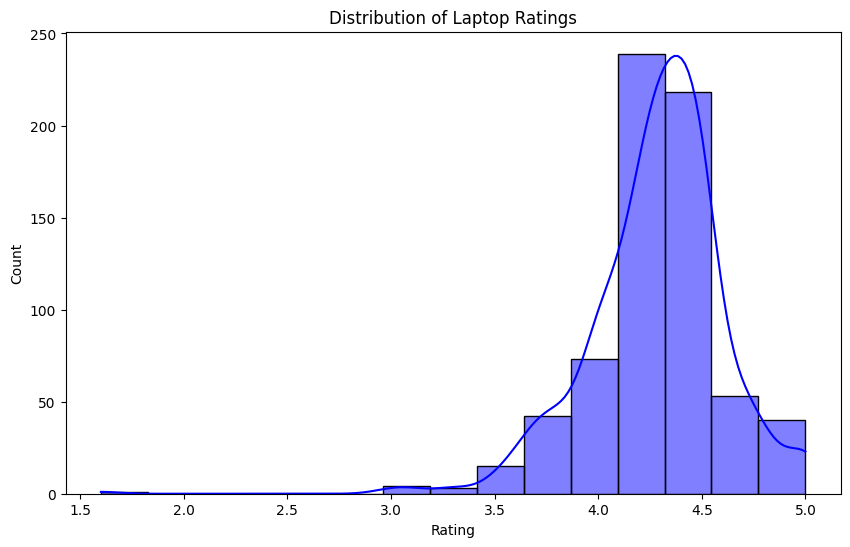

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='rating',
    bins=15,
    kde=True,
    color='blue'
)

plt.title("Distribution of Laptop Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()